# SoftCAM-Transformer v3 — Run B7 (mix=0.15, tous les fixes B5)

## Récapitulatif des runs précédents

| Run | mix cible | warm-up | anneal γ | LayerNorm | R² | Spearman |
|-----|-----------|---------|----------|-----------|-----|----------|
| A | 0 | — | — | — | +0.53 | 0.92 |
| B | 0.3 | ❌ | ❌ | ❌ | −2.83 | 0.33 |
| B2 | 0.3 | ✅ | ✅ | ❌ | −1.97 | 0.80 |
| B3 | 0.3 | ✅ | ✅ | ✅ | −1.59 | 0.78 |
| B4 | 0.10 | ❌ | ❌ | ✅ | −3.58 | 0.44 |
| **B5** | **0.05** | ✅ | ✅ | ✅ | **+0.66** | **0.92** |
| B6 | 0.10 | ✅ | ✅ | ✅ | ? | ? |
| **B7** | **0.15** | ✅ | ✅ | ✅ | **?** | **?** |

## Différence vs Run B5

Un seul paramètre change : `EVIDENCE_MIX_TARGET = 0.15` (B5 avait 0.05).
Tous les schedules, seeds, epochs et hyperparamètres sont identiques.

## Question de recherche

> Mix=0.15 avec warm-up donne-t-il de meilleures métriques que mix=0.05 ?
> Attention : B3 (mix=0.30 avec warm-up) → R²=-1.59 — trop grand = dégradation.

> Avant de lancer : Runtime → Change runtime type → **T4 GPU**.


## 1 — Setup

In [1]:
import subprocess
gpu = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(gpu.stdout if gpu.returncode == 0 else 'Pas de GPU — vérifier le runtime.')

Mon May 18 23:26:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%capture
!pip install -q transformers datasets "gluonts[torch]" accelerate evaluate scipy scikit-learn tqdm openpyxl ujson

## 2 — Récupération du code

In [3]:
import os, sys

REPO_URL = 'https://github.com/theblackmamba08/recherche-m2-xai-faas.git'
REPO_DIR = '/content/recherche-m2-xai-faas'

ipy = get_ipython()
if not os.path.isdir(REPO_DIR):
    ipy.system(f'git clone {REPO_URL} {REPO_DIR}')
else:
    ipy.system(f'git -C {REPO_DIR} pull')

if f'{REPO_DIR}/code' not in sys.path:
    sys.path.insert(0, f'{REPO_DIR}/code')

models_dir = f'{REPO_DIR}/code/src/models'
if not os.path.isdir(models_dir):
    raise FileNotFoundError(
        f'{models_dir} introuvable.\n'
        'Essaie : Runtime → Disconnect and delete runtime, puis relance la cellule.'
    )
print('Repo prêt :', os.listdir(models_dir))

Cloning into '/content/recherche-m2-xai-faas'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (500/500), done.
remote: Compressing objects: 100% (294/294), done.
remote: Total 634 (delta 326), reused 377 (delta 204), pack-reused 134 (from 1)
Receiving objects: 100% (634/634), 71.81 MiB | 21.60 MiB/s, done.
Resolving deltas: 100% (348/348), done.
Repo prêt : ['softcam_transformer_v3.py', 'softcam_transformer_v2.py', '__init__.py', 'softcam_transformer.py']


## 3 — Imports, seed, config

In [4]:
import random, json, gc
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from functools import lru_cache, partial
from pathlib import Path
from tqdm.notebook import tqdm

SEED = 998
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4


In [5]:
# ── Hyperparams (identiques à Run B5) ─────────────────────────
FREQ              = '1T'
PREDICTION_LENGTH = 120
CONTEXT_LENGTH    = 240
D_MODEL           = 32
N_HEADS           = 2
ENCODER_LAYERS    = 4
DECODER_LAYERS    = 4
EMBEDDING_DIM     = [2]
DROPOUT           = 0.1
BATCH_SIZE_TRAIN  = 256
BATCH_SIZE_TEST   = 64
NUM_BATCHES_EPOCH = 100
LR                = 6e-4
BETAS             = (0.9, 0.95)
WEIGHT_DECAY      = 1e-1
GRAD_CLIP_NORM    = 1.0
NUM_EPOCHS        = 51

# ── Evidence Layer v3 — seul changement vs B5 : MIX_TARGET ──
USE_EVIDENCE_LAYER   = True
EVIDENCE_MIX_TARGET  = 0.15          # ← 0.05 en B5
ALPHA_L1             = 0.0
BETA_L2              = 1e-3
GAMMA_ENTROPY_TARGET = 1e-3

# ── Schedules (identiques B5) ────────────────────────────────
MIX_WARMUP_END     = 15
MIX_RAMP_END       = 35
GAMMA_ANNEAL_START = 25
GAMMA_ANNEAL_END   = 40

def mix_schedule(epoch: int) -> float:
    if epoch < MIX_WARMUP_END:
        return 0.0
    if epoch < MIX_RAMP_END:
        return EVIDENCE_MIX_TARGET * (epoch - MIX_WARMUP_END) / (MIX_RAMP_END - MIX_WARMUP_END)
    return EVIDENCE_MIX_TARGET

def gamma_schedule(epoch: int) -> float:
    if epoch < GAMMA_ANNEAL_START:
        return 0.0
    if epoch < GAMMA_ANNEAL_END:
        return GAMMA_ENTROPY_TARGET * (epoch - GAMMA_ANNEAL_START) / (GAMMA_ANNEAL_END - GAMMA_ANNEAL_START)
    return GAMMA_ENTROPY_TARGET

# ── GATE H1.C ────────────────────────────────────────────────
GATE_R2    = 0.30
GATE_SPEAR = 0.85

# ── Références ────────────────────────────────────────────────
RUNA_R2,   RUNA_SPEAR  = 0.5299,  0.9176
RUNB_R2,   RUNB_SPEAR  = -2.8251, 0.3301
RUNB2_R2,  RUNB2_SPEAR = -1.9660, 0.8028
RUNB3_R2,  RUNB3_SPEAR = -1.5894, 0.7771
RUNB4_R2,  RUNB4_SPEAR = -3.5849, 0.4412
RUNB5_R2,  RUNB5_SPEAR = 0.6628,  0.9222
FAYAM_R2,  FAYAM_SPEAR = 0.3701,  0.9201

CLUSTER_ID = 4
RUN_NAME   = f'softcam-cluster{CLUSTER_ID}-v3-runB7'
print(f'Run : {RUN_NAME}')
print(f'Modèle : SoftCAMTransformerV3ForPrediction (Fix #4 LayerNorm)')
print(f'mix target = {EVIDENCE_MIX_TARGET}  (vs 0.05 en B5)')
print(f'Schedule mix : {{0..{MIX_WARMUP_END-1}}}→0   {{{MIX_WARMUP_END}..{MIX_RAMP_END-1}}}→ramp   {{{MIX_RAMP_END}..{NUM_EPOCHS-1}}}→{EVIDENCE_MIX_TARGET}')
print(f'Schedule γ   : {{0..{GAMMA_ANNEAL_START-1}}}→0   {{{GAMMA_ANNEAL_START}..{GAMMA_ANNEAL_END-1}}}→ramp   {{{GAMMA_ANNEAL_END}..{NUM_EPOCHS-1}}}→{GAMMA_ENTROPY_TARGET:.0e}')
print(f'GATE H1.C : R²≥{GATE_R2}  Spearman≥{GATE_SPEAR}')
print(f'Référence B5 : R²={RUNB5_R2}  Spearman={RUNB5_SPEAR}')

Run : softcam-cluster4-v3-runB7
Modèle : SoftCAMTransformerV3ForPrediction (Fix #4 LayerNorm)
mix target = 0.15  (vs 0.05 en B5)
Schedule mix : {0..14}→0   {15..34}→ramp   {35..50}→0.15
Schedule γ   : {0..24}→0   {25..39}→ramp   {40..50}→1e-03
GATE H1.C : R²≥0.3  Spearman≥0.85
Référence B5 : R²=0.6628  Spearman=0.9222


## 4 — Visualisation des schedules

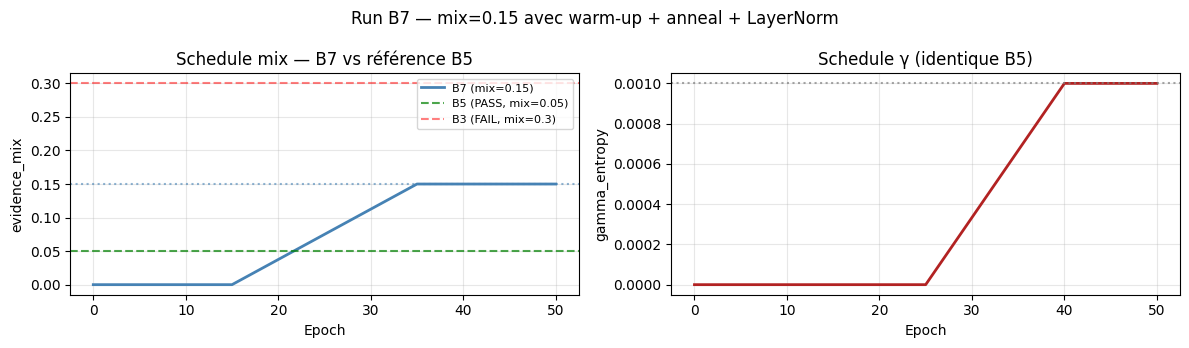

In [6]:
ep_axis = np.arange(NUM_EPOCHS)
mix_vals   = np.array([mix_schedule(e) for e in ep_axis])
gamma_vals = np.array([gamma_schedule(e) for e in ep_axis])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(ep_axis, mix_vals, color='steelblue', lw=2, label='B7 (mix=0.15)')
axes[0].axhline(EVIDENCE_MIX_TARGET, color='steelblue', linestyle=':', alpha=0.6)
axes[0].axhline(0.05, color='green', linestyle='--', alpha=0.7, label='B5 (PASS, mix=0.05)')
axes[0].axhline(0.3, color='red', linestyle='--', alpha=0.5, label='B3 (FAIL, mix=0.3)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('evidence_mix')
axes[0].set_title('Schedule mix — B7 vs référence B5')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(ep_axis, gamma_vals, color='firebrick', lw=2)
axes[1].axhline(GAMMA_ENTROPY_TARGET, color='gray', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('gamma_entropy')
axes[1].set_title('Schedule γ (identique B5)')
axes[1].grid(alpha=0.3)

plt.suptitle('Run B7 — mix=0.15 avec warm-up + anneal + LayerNorm', fontsize=12)
plt.tight_layout()
plt.show()

## 5 — Google Drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = f'/content/drive/MyDrive/m2-xai-faas/experiments/{RUN_NAME}'
for subdir in ['checkpoints', 'results', 'logs', 'figures']:
    os.makedirs(f'{DRIVE_BASE}/{subdir}', exist_ok=True)
print(f'Dossier run : {DRIVE_BASE}')

Mounted at /content/drive
Dossier run : /content/drive/MyDrive/m2-xai-faas/experiments/softcam-cluster4-v3-runB7


## 6 — Chargement Cluster 4

In [8]:
from datasets import Dataset

try:
    from google.colab import drive as _drive  # noqa: F401
    DATA_DIR = Path('/content/drive/MyDrive/Recherche/Datasets')
except ImportError:
    DATA_DIR = Path('../../memoire/06-datasets/raw').resolve()

START_DATE = '2021-01-01 00:00:00'

df = pd.read_csv(DATA_DIR / f'cluster_{CLUSTER_ID}.csv', index_col='Function')
all_series = []
for func_id, row in df.iterrows():
    all_series.append({
        'function_id': int(func_id),
        'cluster':     CLUSTER_ID,
        'target_full': row.values.astype(np.float32),
    })

print(f'Cluster {CLUSTER_ID} — {len(all_series)} fonctions :')
for s in all_series:
    print(f"  function_id={s['function_id']}  longueur={len(s['target_full'])}  "
          f"moy={s['target_full'].mean():.0f}  max={s['target_full'].max():.0f}")

train_rows, test_rows = [], []
for ts_idx, s in enumerate(all_series):
    base = {'start': START_DATE, 'feat_static_cat': [ts_idx],
            'cluster': s['cluster'], 'function_id': s['function_id']}
    train_rows.append({**base, 'target': s['target_full'][:-PREDICTION_LENGTH].tolist()})
    test_rows.append( {**base, 'target': s['target_full'].tolist()})

train_dataset = Dataset.from_list(train_rows)
test_dataset  = Dataset.from_list(test_rows)
print(f'\nDatasets : train={len(train_dataset)}  test={len(test_dataset)}')

Cluster 4 — 5 fonctions :
  function_id=949  longueur=20160  moy=97  max=294
  function_id=951  longueur=20160  moy=95  max=291
  function_id=952  longueur=20160  moy=106  max=351
  function_id=953  longueur=20160  moy=90  max=240
  function_id=954  longueur=20160  moy=97  max=305

Datasets : train=5  test=5


## 7 — Pipeline GluonTS

In [9]:
from gluonts.time_feature import get_lags_for_frequency, time_features_from_frequency_str
from gluonts.dataset.field_names import FieldName
from gluonts.transform import (
    AddAgeFeature, AddObservedValuesIndicator, AddTimeFeatures,
    AsNumpyArray, Chain, ExpectedNumInstanceSampler, InstanceSplitter,
    RemoveFields, TestSplitSampler, ValidationSplitSampler,
    VstackFeatures, RenameFields,
)
from gluonts.itertools import Cyclic, Cached
from gluonts.dataset.loader import as_stacked_batches

lags_sequence = get_lags_for_frequency(FREQ)
time_features  = time_features_from_frequency_str(FREQ)

@lru_cache(10_000)
def convert_to_pandas_period(date, freq):
    return pd.Period(date, freq)

def transform_start_field(batch, freq):
    batch['start'] = [convert_to_pandas_period(d, freq) for d in batch['start']]
    return batch

for ds in (train_dataset, test_dataset):
    ds.set_transform(partial(transform_start_field, freq=FREQ))

print(f'Lags : {len(lags_sequence)} (max={max(lags_sequence)})')
print(f'Time features : {len(time_features)}')

Lags : 22 (max=182)
Time features : 5


/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/lag.py:104: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)
/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


In [10]:
def create_transformation(freq, config):
    remove_field_names = []
    if config.num_static_real_features == 0:
        remove_field_names.append(FieldName.FEAT_STATIC_REAL)
    if config.num_dynamic_real_features == 0:
        remove_field_names.append(FieldName.FEAT_DYNAMIC_REAL)
    if config.num_static_categorical_features == 0:
        remove_field_names.append(FieldName.FEAT_STATIC_CAT)
    return Chain(
        [RemoveFields(field_names=remove_field_names)]
        + ([AsNumpyArray(field=FieldName.FEAT_STATIC_CAT, expected_ndim=1, dtype=int)]
           if config.num_static_categorical_features > 0 else [])
        + [AsNumpyArray(field=FieldName.TARGET, expected_ndim=1),
           AddObservedValuesIndicator(target_field=FieldName.TARGET,
                                      output_field=FieldName.OBSERVED_VALUES),
           AddTimeFeatures(start_field=FieldName.START, target_field=FieldName.TARGET,
                           output_field=FieldName.FEAT_TIME,
                           time_features=time_features_from_frequency_str(freq),
                           pred_length=config.prediction_length),
           AddAgeFeature(target_field=FieldName.TARGET, output_field=FieldName.FEAT_AGE,
                         pred_length=config.prediction_length, log_scale=True),
           VstackFeatures(output_field=FieldName.FEAT_TIME,
                          input_fields=[FieldName.FEAT_TIME, FieldName.FEAT_AGE]),
           RenameFields(mapping={
               FieldName.FEAT_STATIC_CAT: 'static_categorical_features',
               FieldName.FEAT_TIME:       'time_features',
               FieldName.TARGET:          'values',
               FieldName.OBSERVED_VALUES: 'observed_mask',
           })]
    )

def create_instance_splitter(config, mode):
    sampler = {
        'train':      ExpectedNumInstanceSampler(num_instances=1.0,
                                                  min_future=config.prediction_length),
        'validation': ValidationSplitSampler(min_future=config.prediction_length),
        'test':       TestSplitSampler(),
    }[mode]
    return InstanceSplitter(
        target_field='values', is_pad_field=FieldName.IS_PAD,
        start_field=FieldName.START, forecast_start_field=FieldName.FORECAST_START,
        instance_sampler=sampler,
        past_length=config.context_length + max(config.lags_sequence),
        future_length=config.prediction_length,
        time_series_fields=['time_features', 'observed_mask'],
    )

def _pred_fields(config):
    f = ['past_time_features', 'past_values', 'past_observed_mask', 'future_time_features']
    if config.num_static_categorical_features > 0:
        f.append('static_categorical_features')
    return f

def create_train_dataloader(config, freq, data, batch_size, num_batches_per_epoch):
    fields = _pred_fields(config) + ['future_values', 'future_observed_mask']
    tr = create_transformation(freq, config)
    td = Cached(tr.apply(data, is_train=True))
    sp = create_instance_splitter(config, 'train')
    return as_stacked_batches(sp.apply(Cyclic(td).stream()),
                              batch_size=batch_size, field_names=fields,
                              output_type=torch.tensor,
                              num_batches_per_epoch=num_batches_per_epoch)

def create_backtest_dataloader(config, freq, data, batch_size):
    tr = create_transformation(freq, config)
    sp = create_instance_splitter(config, 'validation')
    return as_stacked_batches(sp.apply(tr.apply(data), is_train=True),
                              batch_size=batch_size, output_type=torch.tensor,
                              field_names=_pred_fields(config))

print('Pipeline GluonTS prête.')

Pipeline GluonTS prête.


## 8 — Construction du modèle v3 (LayerNorm)

mix=0 et γ=0 à l'initialisation (epoch 0). Schedules pilotent ensuite.


In [11]:
from src.models.softcam_transformer_v3 import (
    SoftCAMTransformerV3Config,
    SoftCAMTransformerV3ForPrediction,
)

cfg = SoftCAMTransformerV3Config(
    prediction_length=PREDICTION_LENGTH,
    context_length=CONTEXT_LENGTH,
    lags_sequence=lags_sequence,
    num_time_features=len(time_features) + 1,
    num_static_categorical_features=1,
    cardinality=[len(train_dataset)],
    embedding_dimension=EMBEDDING_DIM,
    encoder_layers=ENCODER_LAYERS,
    decoder_layers=DECODER_LAYERS,
    d_model=D_MODEL,
    encoder_attention_heads=N_HEADS,
    decoder_attention_heads=N_HEADS,
    encoder_ffn_dim=max(D_MODEL, 32),
    decoder_ffn_dim=max(D_MODEL, 32),
    dropout=DROPOUT,
    use_evidence_layer=USE_EVIDENCE_LAYER,
    evidence_mix=mix_schedule(0),
    alpha_l1=ALPHA_L1,
    beta_l2=BETA_L2,
    gamma_entropy=gamma_schedule(0),
)

model = SoftCAMTransformerV3ForPrediction(cfg).to(device)

n_params   = sum(p.numel() for p in model.parameters())
n_evidence = sum(p.numel() for p in model.evidence_linear.parameters())
n_norm     = sum(p.numel() for p in model.evidence_norm.parameters())
n_parent   = n_params - n_evidence - n_norm
print(f'Paramètres totaux       : {n_params:,}')
print(f'  dont parent FAYAM     : {n_parent:,}')
print(f'  dont evidence_linear  : {n_evidence:,}')
print(f'  dont evidence_norm    : {n_norm:,}')
print(f'\nÀ epoch 0 : mix={model.evidence_mix:.3f}  γ={model.gamma_entropy:.0e}')
print(f'Cibles    : mix={EVIDENCE_MIX_TARGET}    γ={GAMMA_ENTROPY_TARGET:.0e}')

Paramètres totaux       : 102,173
  dont parent FAYAM     : 94,189
  dont evidence_linear  : 7,920
  dont evidence_norm    : 64

À epoch 0 : mix=0.000  γ=0e+00
Cibles    : mix=0.15    γ=1e-03


## 9 — Helper d'évaluation

In [12]:
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

@torch.no_grad()
def evaluate(model, dataloader, dataset, config, device, prefix=''):
    model.eval()
    forecasts = []
    for b in dataloader:
        out = model.generate(
            static_categorical_features=b['static_categorical_features'].to(device)
                if config.num_static_categorical_features > 0 else None,
            past_time_features=b['past_time_features'].to(device),
            past_values=b['past_values'].to(device),
            future_time_features=b['future_time_features'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
        )
        forecasts.append(out.sequences.cpu().numpy())
    forecasts = np.vstack(forecasts)
    forecast_median = np.median(forecasts, axis=1)

    r2s, spears = [], []
    for ts_idx in range(len(dataset)):
        target = np.array(dataset[ts_idx]['target'])
        actual = target[-config.prediction_length:]
        pred   = forecast_median[ts_idx]
        r2s.append(r2_score(actual, pred))
        rho, _ = spearmanr(actual, pred)
        spears.append(rho)
    r2 = float(np.mean(r2s)); spear = float(np.mean(spears))
    if prefix:
        print(f'{prefix}  R²={r2:.4f}  Spearman={spear:.4f}')
        print(f'{prefix}  per-series R²       : {[f"{x:.3f}" for x in r2s]}')
        print(f'{prefix}  per-series Spearman : {[f"{x:.3f}" for x in spears]}')
    return r2, spear, r2s, spears

print('Helper évaluation prêt.')

Helper évaluation prêt.


## 10 — Entraînement 51 epochs (warm-up + anneal, mix cible 0.15)

À chaque epoch :
1. `model.evidence_mix` ← `mix_schedule(epoch)`
2. `model.gamma_entropy` ← `gamma_schedule(epoch)`


In [13]:
from torch.optim import AdamW

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

train_loader = create_train_dataloader(cfg, FREQ, train_dataset, BATCH_SIZE_TRAIN, NUM_BATCHES_EPOCH)
optimizer    = AdamW(model.parameters(), lr=LR, betas=BETAS, weight_decay=WEIGHT_DECAY)

history = {
    'train_loss': [], 'forecast_loss': [], 'elastic_loss': [], 'entropy_loss': [],
    'mix': [], 'gamma_entropy': [],
}
ckpt_path = f'{DRIVE_BASE}/checkpoints/v3_runB7_final.pt'

for epoch in range(NUM_EPOCHS):
    model.evidence_mix  = mix_schedule(epoch)
    model.gamma_entropy = gamma_schedule(epoch)

    model.train()
    losses_total, losses_fc, losses_el, losses_en = [], [], [], []
    pbar = tqdm(train_loader,
                desc=f'Ep {epoch:03d}/{NUM_EPOCHS-1}  mix={model.evidence_mix:.3f}  γ={model.gamma_entropy:.0e}',
                leave=False)
    for b in pbar:
        optimizer.zero_grad()
        out = model(
            static_categorical_features=b['static_categorical_features'].to(device),
            past_time_features=b['past_time_features'].to(device),
            past_values=b['past_values'].to(device),
            future_time_features=b['future_time_features'].to(device),
            future_values=b['future_values'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
            future_observed_mask=b['future_observed_mask'].to(device),
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        losses_total.append(out.loss.item())
        if out.forecast_loss is not None: losses_fc.append(out.forecast_loss.item())
        if out.elastic_loss  is not None: losses_el.append(out.elastic_loss.item())
        if out.entropy_loss  is not None: losses_en.append(out.entropy_loss.item())
        pbar.set_postfix({'loss': f'{out.loss.item():.3f}'})

    history['train_loss'].append(float(np.mean(losses_total)))
    history['forecast_loss'].append(float(np.mean(losses_fc)) if losses_fc else 0.0)
    history['elastic_loss'].append(float(np.mean(losses_el)) if losses_el else 0.0)
    history['entropy_loss'].append(float(np.mean(losses_en)) if losses_en else 0.0)
    history['mix'].append(model.evidence_mix)
    history['gamma_entropy'].append(model.gamma_entropy)

    print(f'Ep {epoch:03d}  mix={model.evidence_mix:.3f}  γ={model.gamma_entropy:.0e}  '
          f'loss={history["train_loss"][-1]:.4f}  '
          f'fc={history["forecast_loss"][-1]:.4f}  '
          f'el={history["elastic_loss"][-1]:.4f}  '
          f'H(M)={history["entropy_loss"][-1]:.4f}')

torch.save({
    'epoch': NUM_EPOCHS - 1, 'model': model.state_dict(),
    'history': history, 'hyperparameters': cfg.to_dict(),
    'final_mix': model.evidence_mix, 'final_gamma': model.gamma_entropy,
}, ckpt_path)
print(f'\nEntraînement terminé — {NUM_EPOCHS} epochs')
print(f'État final : mix={model.evidence_mix:.3f}  γ={model.gamma_entropy:.0e}')

/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


Ep 000/50  mix=0.000  γ=0e+00: 0it [00:00, ?it/s]

/tmp/ipykernel_17023/2071285507.py:17: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  return pd.Period(date, freq)


Ep 000  mix=0.000  γ=0e+00  loss=5.6639  fc=5.6639  el=0.0000  H(M)=0.0000


Ep 001/50  mix=0.000  γ=0e+00: 0it [00:00, ?it/s]

...

Ep 048  mix=0.150  γ=1e-03  loss=3.9658  fc=3.9609  el=0.0000  H(M)=0.0049


Ep 049/50  mix=0.150  γ=1e-03: 0it [00:00, ?it/s]

Ep 049  mix=0.150  γ=1e-03  loss=3.9817  fc=3.9768  el=0.0000  H(M)=0.0049


Ep 050/50  mix=0.150  γ=1e-03: 0it [00:00, ?it/s]

Ep 050  mix=0.150  γ=1e-03  loss=3.9635  fc=3.9586  el=0.0000  H(M)=0.0049

Entraînement terminé — 51 epochs
État final : mix=0.150  γ=1e-03


## 11 — Courbes de loss + schedules effectifs

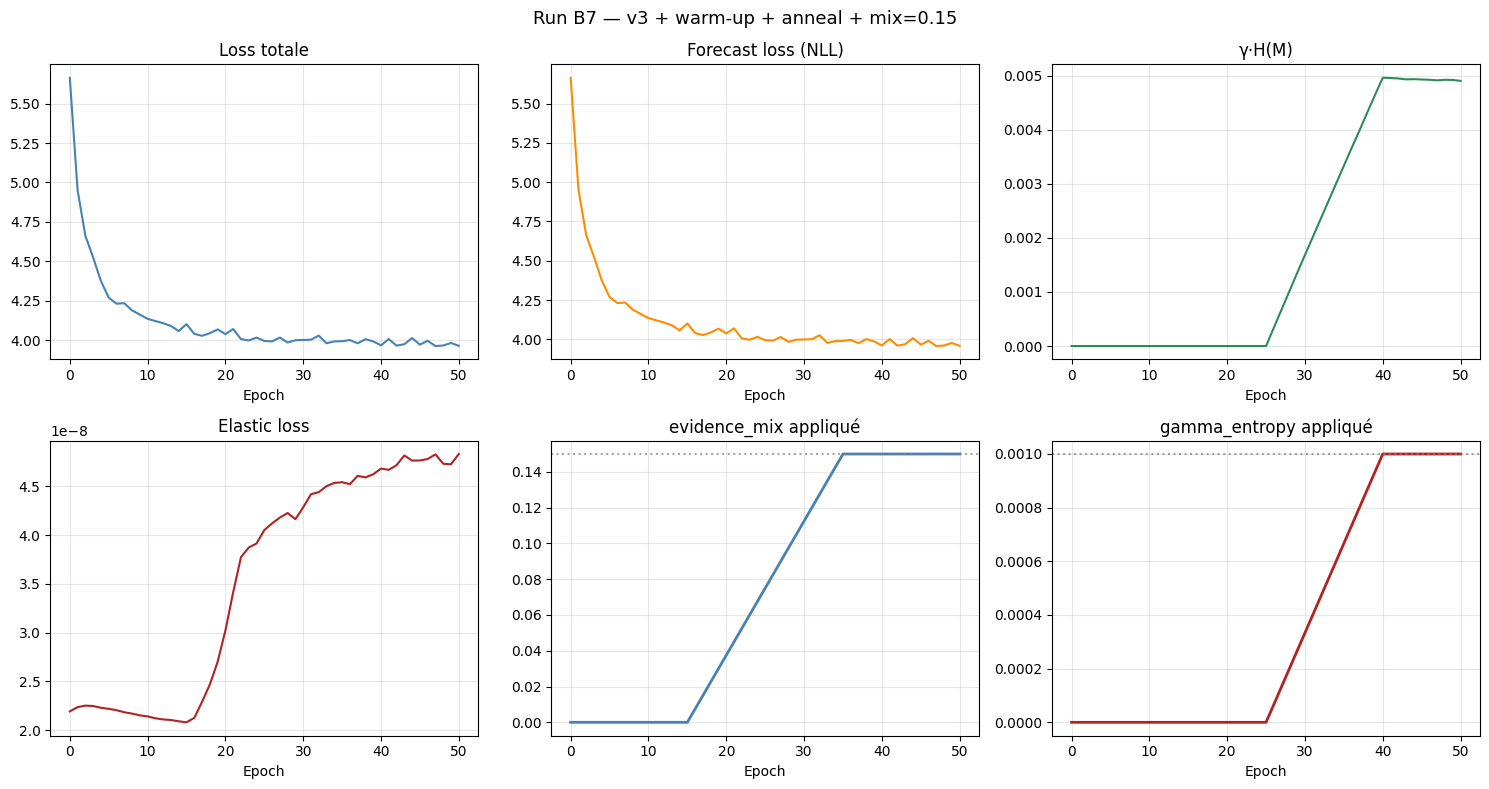

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
ep = list(range(len(history['train_loss'])))

pairs_top = [
    (axes[0, 0], 'train_loss',    'steelblue',  'Loss totale'),
    (axes[0, 1], 'forecast_loss', 'darkorange', 'Forecast loss (NLL)'),
    (axes[0, 2], 'entropy_loss',  'seagreen',   'γ·H(M)'),
]
for ax, key, color, title in pairs_top:
    ax.plot(ep, history[key], lw=1.5, color=color)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)

axes[1, 0].plot(ep, history['elastic_loss'], lw=1.5, color='firebrick')
axes[1, 0].set_title('Elastic loss'); axes[1, 0].set_xlabel('Epoch'); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(ep, history['mix'], lw=2, color='steelblue')
axes[1, 1].axhline(EVIDENCE_MIX_TARGET, color='gray', linestyle=':', alpha=0.7)
axes[1, 1].set_title('evidence_mix appliqué'); axes[1, 1].set_xlabel('Epoch'); axes[1, 1].grid(alpha=0.3)

axes[1, 2].plot(ep, history['gamma_entropy'], lw=2, color='firebrick')
axes[1, 2].axhline(GAMMA_ENTROPY_TARGET, color='gray', linestyle=':', alpha=0.7)
axes[1, 2].set_title('gamma_entropy appliqué'); axes[1, 2].set_xlabel('Epoch'); axes[1, 2].grid(alpha=0.3)

plt.suptitle(f'Run B7 — v3 + warm-up + anneal + mix={EVIDENCE_MIX_TARGET}', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/figures/training_curves.png', dpi=150)
plt.show()

## 12 — Évaluation finale + GATE H1.C

In [15]:
test_loader = create_backtest_dataloader(cfg, FREQ, test_dataset, BATCH_SIZE_TEST)
test_r2, test_spear, test_r2s, test_spears = evaluate(
    model, test_loader, test_dataset, cfg, device, prefix='TEST'
)

results = {
    'run': RUN_NAME,
    'mode': 'evidence-layer-on-warmup-anneal-layernorm-mix015',
    'model_version': 'v3',
    'fix_combo': 'warm-up + anneal γ + LayerNorm + mix=0.15',
    'use_evidence_layer': USE_EVIDENCE_LAYER,
    'evidence_mix_target': EVIDENCE_MIX_TARGET,
    'evidence_mix_final': float(model.evidence_mix),
    'gamma_entropy_target': GAMMA_ENTROPY_TARGET,
    'gamma_entropy_final': float(model.gamma_entropy),
    'mix_warmup_end': MIX_WARMUP_END,
    'mix_ramp_end': MIX_RAMP_END,
    'gamma_anneal_start': GAMMA_ANNEAL_START,
    'gamma_anneal_end': GAMMA_ANNEAL_END,
    'num_epochs': NUM_EPOCHS,
    'test_r2_mean': test_r2,
    'test_spear_mean': test_spear,
    'test_r2_per_series': test_r2s,
    'test_spear_per_series': test_spears,
    'gate_r2': GATE_R2,
    'gate_spear': GATE_SPEAR,
    'runa_r2': RUNA_R2,   'runa_spear': RUNA_SPEAR,
    'runb5_r2': RUNB5_R2, 'runb5_spear': RUNB5_SPEAR,
    'fayam_r2': FAYAM_R2, 'fayam_spear': FAYAM_SPEAR,
    'delta_r2_vs_runb5_pp':  (test_r2  - RUNB5_R2) * 100,
    'delta_r2_vs_runa_pp':   (test_r2  - RUNA_R2)  * 100,
    'delta_spear_vs_runb5_pp': (test_spear - RUNB5_SPEAR) * 100,
    'hyperparameters': cfg.to_dict(),
}
with open(f'{DRIVE_BASE}/results/test_metrics.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)

gate_r2_ok    = test_r2    >= GATE_R2
gate_spear_ok = test_spear >= GATE_SPEAR

print()
print('=' * 72)
print('  GATE H1.C — SoftCAM v3 Run B7 (mix=0.15 + warm-up + anneal + LayerNorm)')
print('=' * 72)
print(f'  Test R²       : {test_r2:.4f}  (gate≥{GATE_R2})   {"PASS" if gate_r2_ok    else "FAIL"}')
print(f'  Test Spearman : {test_spear:.4f}  (gate≥{GATE_SPEAR})   {"PASS" if gate_spear_ok else "FAIL"}')
print(f'  Δ R²   vs Run B5 : {(test_r2-RUNB5_R2)*100:+.2f} pp   (B5={RUNB5_R2})')
print(f'  Δ R²   vs Run A  : {(test_r2-RUNA_R2)*100:+.2f} pp   (Run A={RUNA_R2})')
print('=' * 72)
verdict = 'PASS' if gate_r2_ok and gate_spear_ok else 'FAIL'
compare = 'meilleur' if test_r2 > RUNB5_R2 else 'moins bon'
print(f'  {verdict} H1.C  →  mix=0.15 est {compare} que B5 (mix=0.05)')
print('=' * 72)

/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


TEST  R²=-1.6244  Spearman=0.7685
TEST  per-series R²       : ['-2.292', '-2.445', '-0.892', '-1.511', '-0.982']
TEST  per-series Spearman : ['0.760', '0.764', '0.795', '0.813', '0.711']

  GATE H1.C — SoftCAM v3 Run B7 (mix=0.15 + warm-up + anneal + LayerNorm)
  Test R²       : -1.6244  (gate≥0.3)   FAIL
  Test Spearman : 0.7685  (gate≥0.85)   FAIL
  Δ R²   vs Run B5 : -228.72 pp   (B5=0.6628)
  Δ R²   vs Run A  : -215.43 pp   (Run A=0.5299)
  FAIL H1.C  →  mix=0.15 est moins bon que B5 (mix=0.05)


## 13 — Extraction des evidence maps M

In [16]:
test_loader_expl = create_backtest_dataloader(cfg, FREQ, test_dataset, batch_size=1)
evidence_maps = []

model.eval()
with torch.no_grad():
    for ts_idx, b in enumerate(test_loader_expl):
        func_id = test_dataset[ts_idx]['function_id']
        target_full = np.array(test_dataset[ts_idx]['target'])
        future_vals = torch.tensor(
            target_full[-PREDICTION_LENGTH:], dtype=torch.float32
        ).unsqueeze(0).to(device)
        future_obs = torch.ones_like(future_vals)

        M = model.explain(
            past_values=b['past_values'].to(device),
            past_time_features=b['past_time_features'].to(device),
            past_observed_mask=b['past_observed_mask'].to(device),
            future_values=future_vals,
            future_time_features=b['future_time_features'].to(device),
            static_categorical_features=b['static_categorical_features'].to(device)
                if cfg.num_static_categorical_features > 0 else None,
            future_observed_mask=future_obs,
        )
        M_np = M.squeeze(0).cpu().numpy()
        evidence_maps.append((func_id, M_np))
        print(f'  func_id={func_id}  M.shape={M_np.shape}  '
              f'argmax_mean={int(M_np.argmax(axis=1).mean())}  '
              f'max_weight={M_np.max():.4f}  '
              f'row_entropy_mean={-(M_np * np.log(M_np.clip(1e-9))).sum(axis=1).mean():.3f}')

print(f'\n{len(evidence_maps)} cartes M extraites.')

  func_id=949  M.shape=(120, 240)  argmax_mean=60  max_weight=0.0866  row_entropy_mean=4.814
  func_id=951  M.shape=(120, 240)  argmax_mean=59  max_weight=0.0869  row_entropy_mean=4.815


/usr/local/lib/python3.12/dist-packages/gluonts/time_feature/_base.py:249: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = to_offset(freq_str)


  func_id=952  M.shape=(120, 240)  argmax_mean=55  max_weight=0.0938  row_entropy_mean=4.717
  func_id=953  M.shape=(120, 240)  argmax_mean=59  max_weight=0.0830  row_entropy_mean=4.784
  func_id=954  M.shape=(120, 240)  argmax_mean=60  max_weight=0.0931  row_entropy_mean=4.711

5 cartes M extraites.


## 14 — Heatmaps + H1.A + H1.D

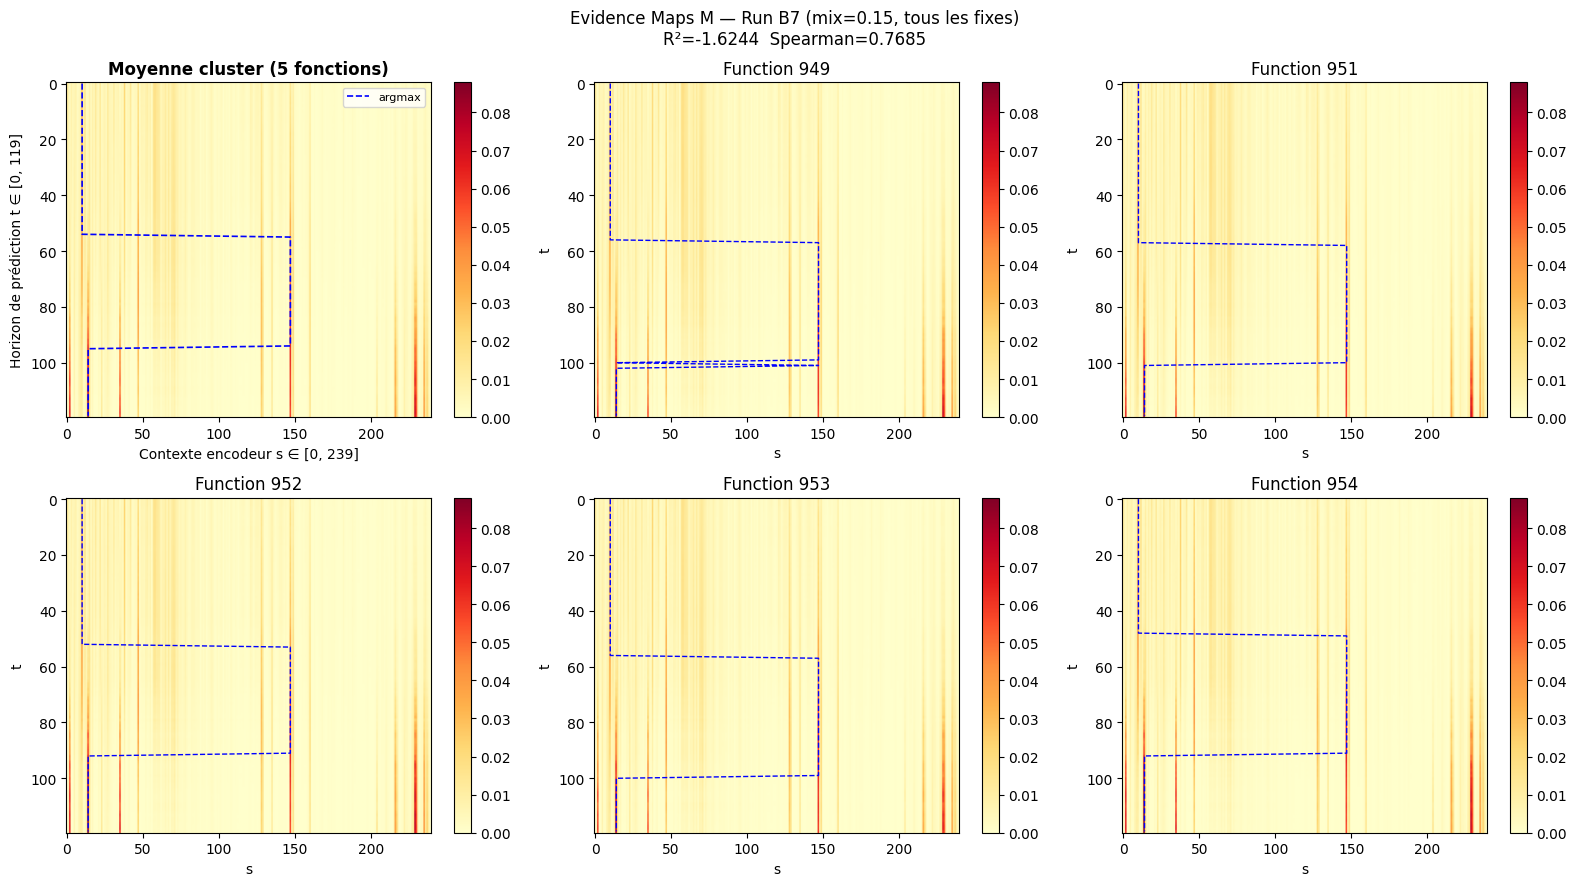

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

M_mean = np.mean([m for _, m in evidence_maps], axis=0)
ax = axes[0]
im = ax.imshow(M_mean, aspect='auto', origin='upper', cmap='YlOrRd', vmin=0, vmax=M_mean.max())
ax.set_title('Moyenne cluster (5 fonctions)', fontweight='bold')
ax.set_xlabel('Contexte encodeur s ∈ [0, 239]')
ax.set_ylabel('Horizon de prédiction t ∈ [0, 119]')
plt.colorbar(im, ax=ax)
argmax_mean = M_mean.argmax(axis=1)
ax.plot(argmax_mean, np.arange(PREDICTION_LENGTH), 'b--', lw=1.2, label='argmax')
ax.legend(loc='upper right', fontsize=8)

for i, (func_id, M_np) in enumerate(evidence_maps):
    ax = axes[i + 1]
    im = ax.imshow(M_np, aspect='auto', origin='upper', cmap='YlOrRd', vmin=0, vmax=M_mean.max())
    ax.set_title(f'Function {func_id}')
    ax.set_xlabel('s'); ax.set_ylabel('t')
    plt.colorbar(im, ax=ax)
    ax.plot(M_np.argmax(axis=1), np.arange(PREDICTION_LENGTH), 'b--', lw=1.0)

plt.suptitle(
    f'Evidence Maps M — Run B7 (mix={EVIDENCE_MIX_TARGET}, tous les fixes)\n'
    f'R²={test_r2:.4f}  Spearman={test_spear:.4f}',
    fontsize=12
)
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/figures/evidence_maps_heatmap.png', dpi=150)
plt.show()

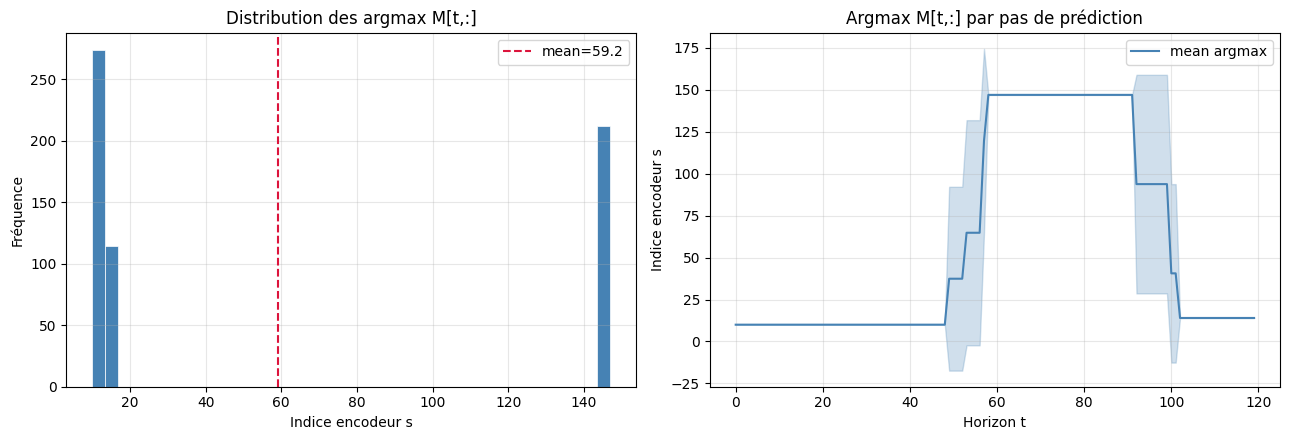

Argmax mean global : 59.2 / 239


In [18]:
# H1.A
all_argmax = np.concatenate([m.argmax(axis=1) for _, m in evidence_maps])
argmax_matrix = np.stack([m.argmax(axis=1) for _, m in evidence_maps])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(all_argmax, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(all_argmax.mean(), color='crimson', lw=1.5, linestyle='--',
                label=f'mean={all_argmax.mean():.1f}')
axes[0].set_title('Distribution des argmax M[t,:]')
axes[0].set_xlabel('Indice encodeur s'); axes[0].set_ylabel('Fréquence')
axes[0].legend(); axes[0].grid(alpha=0.3)

t = np.arange(PREDICTION_LENGTH)
argmax_m = argmax_matrix.mean(axis=0)
argmax_s = argmax_matrix.std(axis=0)
axes[1].plot(t, argmax_m, color='steelblue', lw=1.5, label='mean argmax')
axes[1].fill_between(t, argmax_m - argmax_s, argmax_m + argmax_s, alpha=0.25, color='steelblue')
axes[1].set_title('Argmax M[t,:] par pas de prédiction')
axes[1].set_xlabel('Horizon t'); axes[1].set_ylabel('Indice encodeur s')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/figures/argmax_profile.png', dpi=150)
plt.show()

print(f'Argmax mean global : {all_argmax.mean():.1f} / 239')

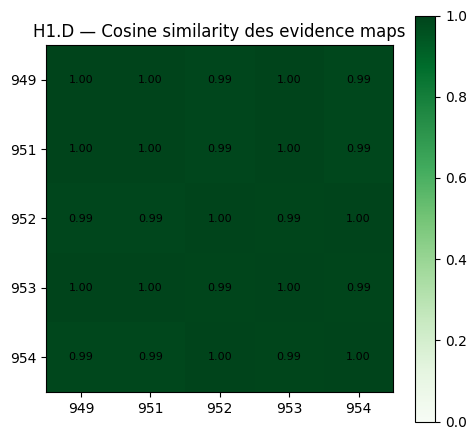

H1.D cosine off-diagonal : mean=0.993  min=0.987


In [19]:
# H1.D
from scipy.spatial.distance import cosine

M_flat   = [m.flatten() for _, m in evidence_maps]
func_ids = [fid for fid, _ in evidence_maps]
n = len(M_flat)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = 1.0 - cosine(M_flat[i], M_flat[j])

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(sim_matrix, cmap='Greens', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(func_ids)
ax.set_yticks(range(n)); ax.set_yticklabels(func_ids)
ax.set_title('H1.D — Cosine similarity des evidence maps')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/figures/coherence_matrix.png', dpi=150)
plt.show()

off_diag = sim_matrix[np.triu_indices(n, k=1)]
print(f'H1.D cosine off-diagonal : mean={off_diag.mean():.3f}  min={off_diag.min():.3f}')

## 15 — Sauvegarde `run.md`

In [20]:
from datetime import datetime, timezone

gate_ok = gate_r2_ok and gate_spear_ok
off_diag = np.array([
    sim_matrix[i, j]
    for i in range(len(evidence_maps)) for j in range(i+1, len(evidence_maps))
])

run_md = f'''# Run {RUN_NAME}

- **Date**     : {datetime.now(timezone.utc).isoformat()}
- **Modèle**   : SoftCAMTransformerV3ForPrediction (LayerNorm Fix #4)
- **Cluster**  : {CLUSTER_ID}
- **Hardware** : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}
- **Epochs**   : {NUM_EPOCHS}

## Configuration — mix=0.15 vs B5 (mix=0.05)

- evidence_mix : 0.0 (epochs 0..14) → ramp (15..34) → **{EVIDENCE_MIX_TARGET}** (35..50)
- gamma_entropy : 0.0 (epochs 0..24) → ramp (25..39) → **{GAMMA_ENTROPY_TARGET:.0e}** (40..50)
- LayerNorm sur h_evidence (v3)
- beta_l2 = {BETA_L2}

## GATE H1.C

| Métrique | Valeur | Seuil | Statut |
|----------|--------|-------|--------|
| Test R² | {test_r2:.4f} | ≥{GATE_R2} | {"PASS" if gate_r2_ok else "FAIL"} |
| Test Spearman | {test_spear:.4f} | ≥{GATE_SPEAR} | {"PASS" if gate_spear_ok else "FAIL"} |

**Verdict H1.C : {"PASS" if gate_ok else "FAIL"}**

## Comparaison 8 runs

| Run | mix | warm-up | anneal γ | LayerNorm | R² | Spearman |
|-----|-----|---------|----------|-----------|-----|---------|
| A | 0 | — | — | — | {RUNA_R2} | {RUNA_SPEAR} |
| B | 0.3 | ❌ | ❌ | ❌ | {RUNB_R2} | {RUNB_SPEAR} |
| B2 | →0.3 | ✅ | ✅ | ❌ | {RUNB2_R2} | {RUNB2_SPEAR} |
| B3 | →0.3 | ✅ | ✅ | ✅ | {RUNB3_R2} | {RUNB3_SPEAR} |
| B4 | 0.10 | ❌ | ❌ | ✅ | {RUNB4_R2} | {RUNB4_SPEAR} |
| B5 | →0.05 | ✅ | ✅ | ✅ | {RUNB5_R2} | {RUNB5_SPEAR} |
| B6 | →0.10 | ✅ | ✅ | ✅ | (voir run.md B6) | (voir run.md B6) |
| **B7** | **→0.15** | **✅** | **✅** | **✅** | **{test_r2:.4f}** | **{test_spear:.4f}** |

Δ R² vs B5 : {(test_r2-RUNB5_R2)*100:+.2f} pp

## Per-series

| function_id | R² | Spearman |
|-------------|-----|---------|
'''
for ts_idx in range(len(test_dataset)):
    func_id = test_dataset[ts_idx]['function_id']
    run_md += f'| {func_id} | {test_r2s[ts_idx]:.4f} | {test_spears[ts_idx]:.4f} |\n'

run_md += f'''
## H1.A

- Argmax mean global : {all_argmax.mean():.1f} / 239

## H1.D

- Cosine off-diagonal : mean={off_diag.mean():.3f}  min={off_diag.min():.3f}
- Verdict : {"PASS (≥0.7)" if off_diag.mean() >= 0.7 else "ATTENTION (<0.7)"}

## Fichiers

- `figures/training_curves.png`
- `figures/evidence_maps_heatmap.png`
- `figures/argmax_profile.png`
- `figures/coherence_matrix.png`
- `results/test_metrics.json`
- `checkpoints/v3_runB7_final.pt`
'''

with open(f'{DRIVE_BASE}/run.md', 'w') as f:
    f.write(run_md)
print(run_md)

# Run softcam-cluster4-v3-runB7

- **Date**     : 2026-05-18T23:47:01.131359+00:00
- **Modèle**   : SoftCAMTransformerV3ForPrediction (LayerNorm Fix #4)
- **Cluster**  : 4
- **Hardware** : Tesla T4
- **Epochs**   : 51

## Configuration — mix=0.15 vs B5 (mix=0.05)

- evidence_mix : 0.0 (epochs 0..14) → ramp (15..34) → **0.15** (35..50)
- gamma_entropy : 0.0 (epochs 0..24) → ramp (25..39) → **1e-03** (40..50)
- LayerNorm sur h_evidence (v3)
- beta_l2 = 0.001

## GATE H1.C

| Métrique | Valeur | Seuil | Statut |
|----------|--------|-------|--------|
| Test R² | -1.6244 | ≥0.3 | FAIL |
| Test Spearman | 0.7685 | ≥0.85 | FAIL |

**Verdict H1.C : FAIL**

## Comparaison 8 runs

| Run | mix | warm-up | anneal γ | LayerNorm | R² | Spearman |
|-----|-----|---------|----------|-----------|-----|---------|
| A | 0 | — | — | — | 0.5299 | 0.9176 |
| B | 0.3 | ❌ | ❌ | ❌ | -2.8251 | 0.3301 |
| B2 | →0.3 | ✅ | ✅ | ❌ | -1.966 | 0.8028 |
| B3 | →0.3 | ✅ | ✅ | ✅ | -1.5894 | 0.7771 |
| B4 | 0.10 | ❌ | ❌ |